In [1]:
import pandas as pd
import os
from sklearn.svm import SVR
from glob import glob
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import StackingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import IsolationForest
import numpy as np
import matplotlib.pyplot as plt
from features import features
from imblearn.over_sampling import SMOTE
from collections import Counter


import sys
from pathlib import Path

# 导入公共路径
sys.path.append(str(Path("../00_common").resolve()))
from base_path import ROOT

# 输出路径：02 Stacking/t+3/
path = ROOT / "02 Stacking" / "t+3"

# 输入路径：上一步分用户的 CSV
input_folder = ROOT / "01 数据处理" / "07split_by_uid"

# 如果输出目录不存在，就创建
path.mkdir(parents=True, exist_ok=True)

print("输入文件夹：", input_folder)
print("输出路径：", path)




# 挑选出3天pam的值
output_hysteresis = path / "滞后特征"
output_abnormal = path / "异常值编码"
merged_file_path = path / "final.csv"
filtered_file_path = path / "final0.7.csv"
# 主循环中传递滞后窗口大小
lag_window = 7  # 可以灵活调整滞后窗口大小
predict_horizon = 3  # 预测几天后的 pam 变化，例如2表示 t+2


输入文件夹： /home/wei/Data/light/01 数据处理/07split_by_uid
输出路径： /home/wei/Data/light/02 Stacking/t+3


# 1. 创建滞后特征 ==========

In [2]:
features = features  # 假设您有这些特征

input_files = glob(os.path.join(input_folder, "*.csv"))
all_data = []

os.makedirs(output_hysteresis, exist_ok=True)

# 定义滞后特征提取函数
def extract_lagged_features(df, required_columns, lag_window, predict_horizon):
    rows = []
    for i in range(lag_window, len(df)):
        pam_t = df.loc[i, "pam"]
        if i + predict_horizon >= len(df):
            break

        pam_t_future = df.loc[i + predict_horizon, "pam"]

        if pd.isna(pam_t) or pd.isna(pam_t_future):
            continue

        # 提取 t-lag_window 到 t 的特征
        lagged_features = [df.loc[i - j, required_columns] for j in range(lag_window, -1, -1)]
        rolling_window = pd.DataFrame(lagged_features)

        # 计算统计特征
        rolling_mean = rolling_window.mean()
        rolling_std = rolling_window.std()
        rolling_skew = rolling_window.skew()

        # 构造特征行
        row = (list(rolling_window.values.flatten())
               + rolling_mean.tolist()
               + rolling_std.tolist()
               + rolling_skew.tolist()
               + [pam_t_future - pam_t])  # 目标值为 t+horizon 的变化
        rows.append(row)
    return rows

# 主循环处理所有输入文件
for file in input_files:
    df = pd.read_csv(file)
    required_columns = [col for col in features if col in df.columns]

    rows = extract_lagged_features(df, required_columns, lag_window, predict_horizon)

    if rows:
        # 构建列名
        columns = (
            [f"{col}_t-{i}" for i in range(lag_window, -1, -1) for col in required_columns]
            + [f"{col}_mean" for col in required_columns]
            + [f"{col}_std" for col in required_columns]
            + [f"{col}_skew" for col in required_columns]
            + ["target"]
        )

        output_df = pd.DataFrame(rows, columns=columns)
        output_file = os.path.join(output_hysteresis, os.path.basename(file))
        output_df.to_csv(output_file, index=False)
        all_data.append(output_df)

# 2. 异常值编码 ==========

In [3]:
input_folder = output_hysteresis
os.makedirs(output_abnormal, exist_ok=True)

input_files = glob(os.path.join(input_folder, "*.csv"))

for file in input_files:
    data = pd.read_csv(file)


    if data.empty:
        print(f"跳过空文件：{file}")
        continue

    data.fillna(-1, inplace=True)  # 用 -1RF 填充缺失值
    encoded_columns = {}


    if "target" not in data.columns:
        print(f"跳过无 target 文件：{file}")
        continue

    isolation_forest = IsolationForest(contamination=0.05, random_state=42)#IsolationForest 不支持数据中存在 NaN 值，因此需要在调用 fit_predict 前对数据进行处理，
    anomaly_scores = isolation_forest.fit_predict(data.drop(columns=['target']))
    data['anomaly'] = anomaly_scores


    for column in data.columns:
        if column == "target":
            continue

        # if pd.api.types.is_numeric_dtype(data[column]):
        if pd.api.types.is_numeric_dtype(data[column]) and not pd.api.types.is_bool_dtype(data[column]):
            Q1 = data[column].quantile(0.25)
            Q3 = data[column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            encoded_columns[f"{column}_encoded"] = data[column].apply(
                lambda x: 0 if x < lower_bound else (2 if x > upper_bound else 1)
            )

    encoded_data = pd.DataFrame(encoded_columns)
    final_data = pd.concat([data, encoded_data], axis=1)






    # 这里不要再用 final_file_path
    abnormal_file_path = os.path.join(output_abnormal, os.path.basename(file))
    final_data.to_csv(abnormal_file_path, index=False)

    print(f"已生成异常编码文件：{abnormal_file_path}")


已生成异常编码文件：/home/wei/Data/light/02 Stacking/t+3/异常值编码/1.csv
已生成异常编码文件：/home/wei/Data/light/02 Stacking/t+3/异常值编码/2.csv
已生成异常编码文件：/home/wei/Data/light/02 Stacking/t+3/异常值编码/5.csv
已生成异常编码文件：/home/wei/Data/light/02 Stacking/t+3/异常值编码/6.csv
已生成异常编码文件：/home/wei/Data/light/02 Stacking/t+3/异常值编码/8.csv
已生成异常编码文件：/home/wei/Data/light/02 Stacking/t+3/异常值编码/9.csv
已生成异常编码文件：/home/wei/Data/light/02 Stacking/t+3/异常值编码/11.csv
已生成异常编码文件：/home/wei/Data/light/02 Stacking/t+3/异常值编码/12.csv
已生成异常编码文件：/home/wei/Data/light/02 Stacking/t+3/异常值编码/13.csv
已生成异常编码文件：/home/wei/Data/light/02 Stacking/t+3/异常值编码/14.csv
已生成异常编码文件：/home/wei/Data/light/02 Stacking/t+3/异常值编码/15.csv
已生成异常编码文件：/home/wei/Data/light/02 Stacking/t+3/异常值编码/20.csv
已生成异常编码文件：/home/wei/Data/light/02 Stacking/t+3/异常值编码/21.csv
已生成异常编码文件：/home/wei/Data/light/02 Stacking/t+3/异常值编码/22.csv
已生成异常编码文件：/home/wei/Data/light/02 Stacking/t+3/异常值编码/23.csv
已生成异常编码文件：/home/wei/Data/light/02 Stacking/t+3/异常值编码/24.csv
已生成异常编码文件：/home/wei/Data/light/02 Stacking/t+3

# 3. 合成 Final 文件 ==========

In [4]:
directory_path = output_abnormal

csv_files = list(directory_path.glob("*.csv"))

print("当前读取目录：", directory_path)
print("CSV 文件数量：", len(csv_files))
print("前10个文件：", csv_files[:10])

csv_files = [
    os.path.join(directory_path, file_name)
    for file_name in os.listdir(directory_path)
    if file_name.endswith(".csv")
]

if len(csv_files) == 0:
    raise ValueError(f"异常值编码文件夹中没有 CSV 文件：{directory_path}")

all_df = []

for file_path in csv_files:
    try:
        df = pd.read_csv(file_path)

        if df.empty:
            print(f"跳过空 CSV：{file_path}")
            continue

        all_df.append(df)

    except pd.errors.EmptyDataError:
        print(f"跳过无内容 CSV：{file_path}")
        continue

if len(all_df) == 0:
    raise ValueError("所有异常编码 CSV 都是空的，无法合并。请检查滞后特征是否成功生成。")

final_df = pd.concat(all_df, ignore_index=True)
final_df.to_csv(merged_file_path, index=False)

print("最终合并文件已保存：", merged_file_path)
print("最终数据形状：", final_df.shape)

当前读取目录： /home/wei/Data/light/02 Stacking/t+3/异常值编码
CSV 文件数量： 123
前10个文件： [PosixPath('/home/wei/Data/light/02 Stacking/t+3/异常值编码/1.csv'), PosixPath('/home/wei/Data/light/02 Stacking/t+3/异常值编码/2.csv'), PosixPath('/home/wei/Data/light/02 Stacking/t+3/异常值编码/5.csv'), PosixPath('/home/wei/Data/light/02 Stacking/t+3/异常值编码/6.csv'), PosixPath('/home/wei/Data/light/02 Stacking/t+3/异常值编码/8.csv'), PosixPath('/home/wei/Data/light/02 Stacking/t+3/异常值编码/9.csv'), PosixPath('/home/wei/Data/light/02 Stacking/t+3/异常值编码/11.csv'), PosixPath('/home/wei/Data/light/02 Stacking/t+3/异常值编码/12.csv'), PosixPath('/home/wei/Data/light/02 Stacking/t+3/异常值编码/13.csv'), PosixPath('/home/wei/Data/light/02 Stacking/t+3/异常值编码/14.csv')]
最终合并文件已保存： /home/wei/Data/light/02 Stacking/t+3/final.csv
最终数据形状： (4295, 1381)


# 4. 筛选缺失值 ==========

In [5]:
sensor_data = pd.read_csv(merged_file_path)
missing_percentage = sensor_data.isnull().mean() * 100
selected_columns = missing_percentage[missing_percentage <= 30].index.tolist()
filtered_data = sensor_data[selected_columns]
filtered_data.to_csv(filtered_file_path, index=False)

# 5. 数据增强与训练 ==========

In [6]:
data = pd.read_csv(filtered_file_path)
sensor_columns = [col for col in data.columns if col not in ['target']]
data[sensor_columns] = data[sensor_columns].apply(pd.to_numeric, errors='coerce')
data[sensor_columns] = data[sensor_columns].fillna(data[sensor_columns].mean())

# 标准化
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data[sensor_columns])
X = pd.DataFrame(scaled_features, columns=sensor_columns)
y = data['target']

In [7]:
# 数据增强
# 计算每个类别的样本数
class_counts = Counter(y)

# 定义采样策略：对所有类别增加 1RF.05 倍
sampling_strategy = {label: int(class_counts[label] * 1.5) for label in class_counts}

# ADASYN 对全部类别进行采样
adasyn = ADASYN(sampling_strategy='not majority', n_neighbors=3, random_state=42,)
X_resampled, y_resampled = adasyn.fit_resample(X, y)

# 对极端值单独处理
extreme_samples = (np.abs(y) > y.mean() + 2 * y.std())
X_extreme, y_extreme = X[extreme_samples], y[extreme_samples]

# 定义极端值的采样策略
extreme_sampling_strategy = {label: int(len(y_extreme) * 2) for label in set(y_extreme)}

# 使用 SMOTE 增强极端样本
smote_extreme = SMOTE(sampling_strategy=extreme_sampling_strategy, random_state=42, k_neighbors=3)
X_extreme_resampled, y_extreme_resampled = smote_extreme.fit_resample(X_extreme, y_extreme)

# 合并增强后的数据
X_resampled = np.vstack([X_resampled, X_extreme_resampled])
y_resampled = np.hstack([y_resampled, y_extreme_resampled])


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

base_models = [
    ('xgb', XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=8,
        random_state=42
    )),

    ('svm', SVR(C=1.0, kernel='rbf')),
     ('rf', RandomForestRegressor(n_estimators=200, random_state=42))
]

In [9]:
meta_model = CatBoostRegressor(
    n_estimators=300,
    learning_rate=0.03,
    loss_function='MAE',
    depth=10,
    l2_leaf_reg=3,
    random_state=42
)

model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model
)

In [10]:
model.fit(X_train, y_train)

0:	learn: 8.4302561	total: 64.5ms	remaining: 19.3s
1:	learn: 8.1886196	total: 73.8ms	remaining: 11s
2:	learn: 7.9529945	total: 80.8ms	remaining: 8s
3:	learn: 7.7309114	total: 87.5ms	remaining: 6.47s
4:	learn: 7.5094010	total: 94.1ms	remaining: 5.55s
5:	learn: 7.2967087	total: 101ms	remaining: 4.95s
6:	learn: 7.0924843	total: 107ms	remaining: 4.49s
7:	learn: 6.8895480	total: 114ms	remaining: 4.16s
8:	learn: 6.6944871	total: 120ms	remaining: 3.9s
9:	learn: 6.5097956	total: 127ms	remaining: 3.69s
10:	learn: 6.3261868	total: 135ms	remaining: 3.54s
11:	learn: 6.1513642	total: 141ms	remaining: 3.39s
12:	learn: 5.9814170	total: 148ms	remaining: 3.27s
13:	learn: 5.8203444	total: 154ms	remaining: 3.15s
14:	learn: 5.6607804	total: 161ms	remaining: 3.06s
15:	learn: 5.5080606	total: 168ms	remaining: 2.97s
16:	learn: 5.3646376	total: 174ms	remaining: 2.9s
17:	learn: 5.2206641	total: 181ms	remaining: 2.83s
18:	learn: 5.0804323	total: 187ms	remaining: 2.77s
19:	learn: 4.9442360	total: 194ms	remaining

,estimators,"[('xgb', ...), ('svm', ...), ...]"
,final_estimator,CatBoostRegre...ndom_state=42)
,cv,None
,n_jobs,None
,passthrough,False
,verbose,0
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None


# 6. 评估与可视化 ==========


In [11]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"\n测试集上的均方误差（MSE）：{mse}")

# 极端值样本评估
threshold = 2.0
errors = np.abs(y_pred - y_test)
correct_predictions = errors <= threshold

extreme_samples = (np.abs(y_test) > 10)
extreme_mse = mean_squared_error(y_test[extreme_samples], y_pred[extreme_samples])

print(f"\n误差在 {threshold} 范围内的准确率：{np.mean(correct_predictions) * 100:.2f}%")
print(f"极端值样本的MSE：{extreme_mse}")



测试集上的均方误差（MSE）：3.1329969816328513

误差在 2.0 范围内的准确率：83.01%
极端值样本的MSE：0.30027049155893093


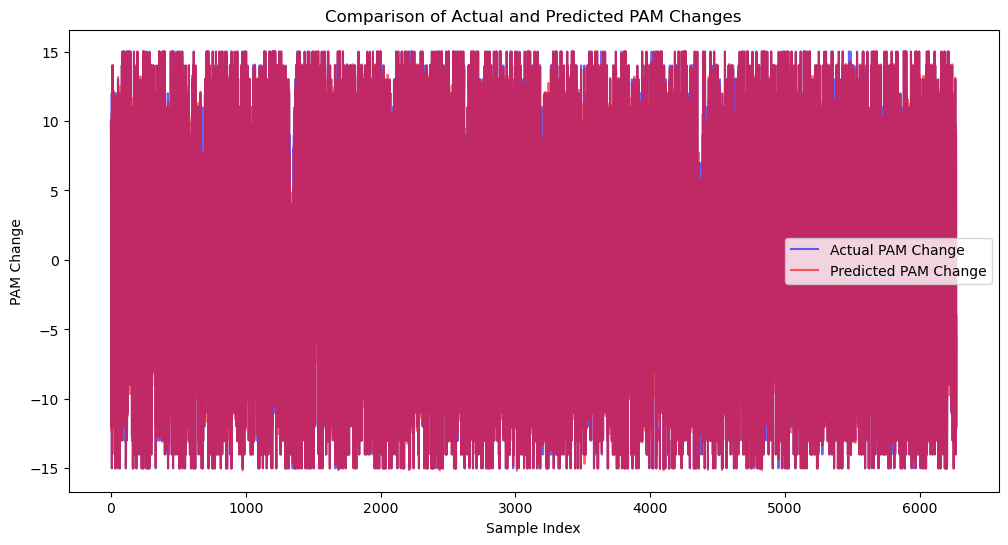

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label="Actual PAM Change", color="blue", alpha=0.6)
plt.plot(y_pred, label="Predicted PAM Change", color="red", alpha=0.6)
plt.legend()
plt.title("Comparison of Actual and Predicted PAM Changes")
plt.xlabel("Sample Index")
plt.ylabel("PAM Change")
plt.show()
